# Pet-mischief-detection

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# INSTALL DEPENDENCIES
# ═══════════════════════════════════════════════════════════════════════════════
%pip install -q ultralytics
%pip install -q opencv-python-headless
%pip install -q certifi
%pip install --index-url https://download.pytorch.org/whl/cu121 torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121

print("✓ Dependencies installed!")


Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.26.0
Uninstalling torchvision-0.26.0:
  Successfully uninstalled torchvision-0.26.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.
You can safely remove it manually.


Files removed: 426
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 33.3 MB/s eta 0:01:14
     ---------------------------------------- 0.0/2.4 GB 52.6 MB/s eta 0:00:47
     ---------------------------------------- 0.0/2.4 GB 52.3 MB/s eta 0:00:47
     ---------------------------------------- 0.0/2.4 GB 52.9 MB/s eta 0:00:47
     ---------------------------------------- 0.0/2.4 GB 59.5 MB/s eta 0:00:41
     ---------------------------------------- 0.0/2.4 GB 59.5 MB/s eta 0:00:41
     ---------------------------------------- 0.0/2.4 GB 59.5 MB/s eta 0:00:41
     ---------------------------------------- 0.0/2.4 GB 65.2 MB/s eta 0:00:38
     ---------------------------------------- 0.0/2.4 GB 65.2 MB/s eta 0:00:38
     ---------------------------------------- 0.0/2.4 GB 65.6 MB/s eta 0:00:37
     ---------------------------------------- 0.0/2.4 GB 59.5 MB/s eta 0:00:41
 


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import platform
import os

print(f"OS: {platform.platform()}")
print(f"CPU Count: {os.cpu_count()}")
!nvidia-smi

import sys, torch
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA devices:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

OS: Windows-10-10.0.26200-SP0
CPU Count: 22
Wed Apr 29 03:23:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P8              4W /   64W |     543MiB /   8188MiB |     20%      Default |
|                                         |                        |                  N/A |
+---

## Global Configuration

Shared parameters used across all tasks. **Run this cell first.**

### Business logic
- The dataset is optimized for pet-mischief detection scenes, not generic COCO performance.
- Target classes are: `cat`, `cup`, `plant`, `laptop`, `keyboard`, `vase`, `scissors`.
- `ANY_TARGET_CLASS` controls inclusion policy:
  - `True`: keep any image containing one or more target classes (max coverage).
  - `False`: keep only images where `cat` co-occurs with at least one other target class (event-focused context).

### Technical controls
- `SEED` fixes deterministic shuffling behavior for reproducible splits.
- `TRAIN_PCT`, `VAL_PCT`, `TEST_PCT` define split strategy (default 80/10/10).
- `TARGET_CLASSES` maps COCO labels to exported training labels (including `potted plant -> plant`).
- `TRAINING_DATA_YAML` points to the dataset used by training cells.

### Design note
A two-stage architecture is used:
1. Build filtered COCO subset + YOLO labels (`coco_filtered/`).
2. Build reproducible train/val/test dataset (`curated_yolo/`) and optional balanced variant (`curated_yolo_balanced/`).

In [13]:
"""
Global Configuration
====================
Shared parameters for the entire pipeline.
"""
from pathlib import Path

# ═══════════════════════════════════════════════════════════════════════════════
# DATASET CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

# Target classes for pet mischief detection
TARGET_CLASSES = {
    "cat": "cat",
    "cup": "cup",
    "laptop": "laptop",
    "keyboard": "keyboard",
    "vase": "vase",
    "potted plant": "plant",
    "scissors": "scissors",
}

# True = any image with target class (more data); False = cat + other required
ANY_TARGET_CLASS = True

# ═══════════════════════════════════════════════════════════════════════════════
# DIRECTORY PATHS
# ═══════════════════════════════════════════════════════════════════════════════

ANNOTATIONS_DIR = Path("data/annotations")
COCO_FILTERED_DIR = Path("coco_filtered")
# curated_yolo_balanced for a class-balanced subset
CURATED_YOLO_DIR = Path("curated_yolo_balanced")
TRAINING_DATA_YAML = CURATED_YOLO_DIR / "data.yaml"

# ═══════════════════════════════════════════════════════════════════════════════
# REPRODUCIBILITY & SPLITS
# ═══════════════════════════════════════════════════════════════════════════════

SEED = 42
TRAIN_PCT, VAL_PCT, TEST_PCT = 80, 10, 10

# ═══════════════════════════════════════════════════════════════════════════════
# DOWNLOAD SETTINGS
# ═══════════════════════════════════════════════════════════════════════════════

# NOTE: Some Windows/.venv environments have TLS interception and fail hostname verification
# for images.cocodataset.org. We default to HTTP to avoid SSL handshake failures.
COCO_ANNOTATIONS_URL = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
COCO_IMAGE_BASE_URL = "http://images.cocodataset.org"
DOWNLOAD_WORKERS = 8
DOWNLOAD_RETRIES = 3
DOWNLOAD_TIMEOUT = 30

# ═══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════════

GRAPH_FILENAMES = ["results.png", "confusion_matrix.png", "BoxF1_curve.png", "BoxR_curve.png", "BoxP_curve.png"]

# Print summary
print("=" * 60)
print("GLOBAL CONFIGURATION LOADED")
print("=" * 60)
print(f"Classes ({len(TARGET_CLASSES)}): {list(TARGET_CLASSES.values())}")
print(f"Filter: {'Any target class' if ANY_TARGET_CLASS else 'Cat + other required'}")
print(f"Split: {TRAIN_PCT}/{VAL_PCT}/{TEST_PCT}")
print(f"Seed: {SEED}")
print(f"Training data: {TRAINING_DATA_YAML}")


GLOBAL CONFIGURATION LOADED
Classes (7): ['cat', 'cup', 'laptop', 'keyboard', 'vase', 'plant', 'scissors']
Filter: Any target class
Split: 80/10/10
Seed: 42
Training data: curated_yolo_balanced\data.yaml


## Task 1: COCO Subset Preparation

Downloads COCO annotations, filters classes, downloads images, converts to YOLO format.

**Output:** `coco_filtered/`

In [8]:
"""
Task 1: COCO Subset Preparation
Uses global config: TARGET_CLASSES, ANY_TARGET_CLASS, ANNOTATIONS_DIR, COCO_FILTERED_DIR
"""
import json
import shutil
import ssl
import sys
import time
import traceback
import urllib.error
import urllib.request
import zipfile
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed


def _build_ssl_context():
    try:
        import certifi

        return ssl.create_default_context(cafile=certifi.where())
    except Exception:
        # Fall back to system trust store if certifi is unavailable.
        # If this still fails, install certifi in the kernel environment.
        return ssl.create_default_context()


SSL_CONTEXT = _build_ssl_context()


def _dbg(enabled, msg):
    if enabled:
        print(f"[DEBUG] {msg}")


def _alt_http_url(url: str) -> str | None:
    https_prefix = "https://images.cocodataset.org"
    if url.startswith(https_prefix):
        return "http://images.cocodataset.org" + url[len(https_prefix):]
    return None


def _open_stream(url: str, debug=False):
    _dbg(debug, f"Opening URL: {url}")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    resp = urllib.request.urlopen(req, timeout=DOWNLOAD_TIMEOUT, context=SSL_CONTEXT)
    _dbg(debug, f"HTTP status={getattr(resp, 'status', 'n/a')} Content-Length={resp.headers.get('Content-Length')}")
    return resp


def _copy_stream_with_progress(resp, out_file, expected, debug=False, label="download"):
    chunk_size = 1024 * 1024  # 1 MiB
    total = 0
    start = time.time()
    next_report = start + 2.0

    while True:
        chunk = resp.read(chunk_size)
        if not chunk:
            break
        out_file.write(chunk)
        total += len(chunk)

        now = time.time()
        if debug and now >= next_report:
            elapsed = max(now - start, 1e-6)
            speed_mib = (total / (1024 * 1024)) / elapsed
            if expected and expected.isdigit():
                pct = (100.0 * total) / int(expected)
                print(f"[DEBUG] {label}: {total}/{expected} bytes ({pct:.1f}%), {speed_mib:.2f} MiB/s")
            else:
                print(f"[DEBUG] {label}: {total} bytes, {speed_mib:.2f} MiB/s")
            next_report = now + 2.0

    return total


def _download(url, dest, desc="", debug=False):
    dest.parent.mkdir(parents=True, exist_ok=True)
    last_err = None

    for attempt in range(1, DOWNLOAD_RETRIES + 1):
        tmp_dest = dest.with_suffix(dest.suffix + ".part")
        try:
            print(f"Downloading {desc or url} (attempt {attempt}/{DOWNLOAD_RETRIES})")
            with _open_stream(url, debug=debug) as resp, tmp_dest.open("wb") as f:
                expected = resp.headers.get("Content-Length")
                _dbg(debug, f"Writing temp file: {tmp_dest}")
                got = _copy_stream_with_progress(resp, f, expected, debug=debug, label=desc or "download")

            _dbg(debug, f"Downloaded bytes: {got}, expected: {expected}")
            if expected is not None and expected.isdigit() and got != int(expected):
                raise RuntimeError(f"Incomplete download: expected {expected} bytes, got {got} bytes")

            tmp_dest.replace(dest)
            _dbg(debug, f"Promoted temp file to final: {dest}")
            return
        except Exception as e:
            last_err = e
            _dbg(debug, f"Attempt {attempt} failed with {type(e).__name__}: {e}")
            _dbg(debug, traceback.format_exc())
            alt = _alt_http_url(url)
            if alt and "Hostname mismatch" in str(e):
                try:
                    print("  SSL hostname mismatch detected, retrying over HTTP...")
                    with _open_stream(alt, debug=debug) as resp, tmp_dest.open("wb") as f:
                        expected = resp.headers.get("Content-Length")
                        got = _copy_stream_with_progress(resp, f, expected, debug=debug, label=f"{desc or 'download'} (HTTP fallback)")

                    _dbg(debug, f"HTTP fallback bytes: {got}, expected: {expected}")
                    if expected is not None and expected.isdigit() and got != int(expected):
                        raise RuntimeError(f"Incomplete download: expected {expected} bytes, got {got} bytes")

                    tmp_dest.replace(dest)
                    _dbg(debug, f"HTTP fallback succeeded: {dest}")
                    return
                except Exception as e2:
                    last_err = e2
                    _dbg(debug, f"HTTP fallback failed with {type(e2).__name__}: {e2}")
                    _dbg(debug, traceback.format_exc())

            if tmp_dest.exists():
                tmp_dest.unlink()
                _dbg(debug, f"Deleted temp file: {tmp_dest}")
            print(f"  download failed: {last_err}")

    raise RuntimeError(f"Failed downloading {desc or url} after {DOWNLOAD_RETRIES} attempts") from last_err


def _is_valid_zip(path, debug=False):
    if not path.is_file() or path.stat().st_size == 0:
        _dbg(debug, f"Zip missing or empty: {path}")
        return False
    try:
        _dbg(debug, f"Validating zip: {path} (size={path.stat().st_size} bytes)")
        with zipfile.ZipFile(path, "r") as zf:
            bad_member = zf.testzip()
            if bad_member is not None:
                _dbg(debug, f"Zip CRC failure at member: {bad_member}")
                return False
        return True
    except zipfile.BadZipFile:
        _dbg(debug, f"BadZipFile while validating: {path}")
        return False


def ensure_annotations(debug=False):
    train_json = ANNOTATIONS_DIR / "instances_train2017.json"
    if train_json.is_file():
        print(f"✓ Annotations exist at {ANNOTATIONS_DIR}")
        return ANNOTATIONS_DIR

    extract_parent = ANNOTATIONS_DIR.parent
    extract_parent.mkdir(parents=True, exist_ok=True)
    zip_path = extract_parent / "annotations_trainval2017.zip"
    _dbg(debug, f"Expected annotations zip path: {zip_path}")

    if not _is_valid_zip(zip_path, debug=debug):
        if zip_path.exists():
            print("Corrupted annotations zip detected; deleting and re-downloading...")
            _dbg(debug, f"Deleting invalid zip: {zip_path}")
            zip_path.unlink()
        _download(COCO_ANNOTATIONS_URL, zip_path, "COCO annotations", debug=debug)

    print(f"Extracting to {extract_parent}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_parent)
    _dbg(debug, "Annotations extracted successfully")
    return ANNOTATIONS_DIR

def filter_split(split_name, ann_path, img_subdir, output_dir):
    with ann_path.open() as f:
        coco = json.load(f)
    
    target_cats = {c["id"]: c["name"] for c in coco["categories"] if c["name"] in TARGET_CLASSES}
    id_remap = {old: new for new, old in enumerate(sorted(target_cats.keys()))}
    export_names = [TARGET_CLASSES[target_cats[oid]] for oid in sorted(target_cats.keys())]
    
    if ANY_TARGET_CLASS:
        kept_ids = {a["image_id"] for a in coco["annotations"] if a["category_id"] in target_cats}
    else:
        cat_id = [cid for cid, name in target_cats.items() if name == "cat"][0]
        other_ids = {cid for cid in target_cats if cid != cat_id}
        by_image = defaultdict(set)
        for a in coco["annotations"]:
            if a["category_id"] in target_cats:
                by_image[a["image_id"]].add(a["category_id"])
        kept_ids = {img_id for img_id, cats in by_image.items() if cat_id in cats and cats & other_ids}
    
    filtered_anns = [a for a in coco["annotations"] if a["category_id"] in target_cats and a["image_id"] in kept_ids]
    filtered_images = [img for img in coco["images"] if img["id"] in kept_ids]
    
    for ann in filtered_anns:
        ann["category_id"] = id_remap[ann["category_id"]]
    
    out_ann_dir = output_dir / "annotations"
    out_ann_dir.mkdir(parents=True, exist_ok=True)
    new_cats = [{"id": new, "name": TARGET_CLASSES[target_cats[old]], "supercategory": "object"} for old, new in id_remap.items()]
    with (out_ann_dir / f"instances_{split_name}.json").open("w") as f:
        json.dump({"categories": new_cats, "images": filtered_images, "annotations": filtered_anns}, f)
    
    print(f"[{split_name}] {len(filtered_images)} images, {len(filtered_anns)} annotations")
    return filtered_images, export_names

def download_images(split_name, img_subdir, filtered_images, output_dir, debug=False):
    out_dir = output_dir / "images" / split_name
    out_dir.mkdir(parents=True, exist_ok=True)
    base = f"{COCO_IMAGE_BASE_URL}/{img_subdir}"

    def fetch(url, dest):
        if dest.is_file():
            return True

        last_err = None
        for _ in range(DOWNLOAD_RETRIES):
            try:
                with _open_stream(url, debug=debug) as resp, dest.open("wb") as f:
                    shutil.copyfileobj(resp, f)
                return True
            except Exception as e:
                last_err = e
                _dbg(debug, f"Image download failed for {dest.name}: {type(e).__name__}: {e}")
                alt = _alt_http_url(url)
                if alt and "Hostname mismatch" in str(e):
                    try:
                        with _open_stream(alt, debug=debug) as resp, dest.open("wb") as f:
                            shutil.copyfileobj(resp, f)
                        return True
                    except Exception as e2:
                        last_err = e2
                        _dbg(debug, f"Image HTTP fallback failed for {dest.name}: {type(e2).__name__}: {e2}")

        print(f"  failed: {dest.name} ({last_err})")
        return False

    tasks = [(f"{base}/{img['file_name']}", out_dir / img["file_name"]) for img in filtered_images]
    print(f"[{split_name}] Downloading {len(tasks)} images...")

    done = 0
    ok_count = 0
    with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as ex:
        for ok in ex.map(lambda t: fetch(*t), tasks):
            done += 1
            if ok:
                ok_count += 1
            if done % 500 == 0:
                print(f"  {done}/{len(tasks)} (ok={ok_count})")

    failed = len(tasks) - ok_count
    print(f"[{split_name}] ✓ Done (ok={ok_count}, failed={failed})")

def coco_to_yolo(ann_json, out_label_dir):
    with ann_json.open() as f:
        data = json.load(f)
    img_info = {img["id"]: img for img in data["images"]}
    ann_by_img = defaultdict(list)
    for ann in data["annotations"]:
        ann_by_img[ann["image_id"]].append(ann)
    
    out_label_dir.mkdir(parents=True, exist_ok=True)
    for img_id, anns in ann_by_img.items():
        meta = img_info[img_id]
        w, h = meta["width"], meta["height"]
        lines = [f"{a['category_id']} {(a['bbox'][0]+a['bbox'][2]/2)/w:.6f} {(a['bbox'][1]+a['bbox'][3]/2)/h:.6f} {a['bbox'][2]/w:.6f} {a['bbox'][3]/h:.6f}" for a in anns]
        (out_label_dir / f"{Path(meta['file_name']).stem}.txt").write_text("\n".join(lines))

def write_data_yaml(output_dir, names):
    lines = [f"path: {output_dir}", "train: images/train", "val: images/val", "", f"nc: {len(names)}", "names:"]
    lines += [f"  {i}: {n}" for i, n in enumerate(names)]
    (output_dir / "data.yaml").write_text("\n".join(lines))

SPLITS_CFG = {"train": ("instances_train2017.json", "train2017"), "val": ("instances_val2017.json", "val2017")}

def run_task1(skip_download=False, debug=False):
    print("=" * 60)
    print("TASK 1: COCO SUBSET PREPARATION")
    print("=" * 60)
    _dbg(debug, f"Python: {sys.version}")
    _dbg(debug, f"skip_download={skip_download}, retries={DOWNLOAD_RETRIES}, timeout={DOWNLOAD_TIMEOUT}s")
    _dbg(debug, f"COCO_ANNOTATIONS_URL={COCO_ANNOTATIONS_URL}")
    _dbg(debug, f"COCO_IMAGE_BASE_URL={COCO_IMAGE_BASE_URL}")

    ann_root = ensure_annotations(debug=debug)
    COCO_FILTERED_DIR.mkdir(parents=True, exist_ok=True)

    names = None
    total = 0
    for split, (ann_file, img_subdir) in SPLITS_CFG.items():
        _dbg(debug, f"Processing split={split}, ann_file={ann_file}, img_subdir={img_subdir}")
        imgs, names = filter_split(split, ann_root / ann_file, img_subdir, COCO_FILTERED_DIR)
        total += len(imgs)
        if not skip_download:
            download_images(split, img_subdir, imgs, COCO_FILTERED_DIR, debug=debug)
        coco_to_yolo(COCO_FILTERED_DIR / "annotations" / f"instances_{split}.json", COCO_FILTERED_DIR / "labels" / split)

    write_data_yaml(COCO_FILTERED_DIR, names)
    print(f"\n✓ Task 1 complete: {total} images -> {COCO_FILTERED_DIR}/")
    return names


In [9]:
# Uncomment to run:
run_task1(skip_download=False, debug=True)

TASK 1: COCO SUBSET PREPARATION
[DEBUG] Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
[DEBUG] skip_download=False, retries=3, timeout=30s
[DEBUG] COCO_ANNOTATIONS_URL=http://images.cocodataset.org/annotations/annotations_trainval2017.zip
[DEBUG] COCO_IMAGE_BASE_URL=http://images.cocodataset.org
[DEBUG] Expected annotations zip path: data\annotations_trainval2017.zip
[DEBUG] Zip missing or empty: data\annotations_trainval2017.zip
[DEBUG] Opening URL: http://images.cocodataset.org/annotations/annotations_trainval2017.zip
[DEBUG] HTTP status=200 Content-Length=252907541
[DEBUG] Writing temp file: data\annotations_trainval2017.zip.part
[DEBUG] COCO annotations: 1048576/252907541 bytes (0.4%), 0.10 MiB/s
[DEBUG] COCO annotations: 2097152/252907541 bytes (0.8%), 0.12 MiB/s
[DEBUG] COCO annotations: 3145728/252907541 bytes (1.2%), 0.13 MiB/s
[DEBUG] COCO annotations: 4194304/252907541 bytes (1.7%), 0.14 MiB/s
[DEBUG] COCO annotations: 5242880/2529075

['cat', 'cup', 'plant', 'laptop', 'keyboard', 'vase', 'scissors']

## Task 2: Dataset Splitting

Creates deterministic train/val/test splits from the filtered YOLO dataset.

**Input:** `coco_filtered/` | **Output:** `curated_yolo/`

### Implementation details
1. Collect valid `(image, label)` pairs from `coco_filtered/images/{train,val}`.
2. Shuffle pair indices using `SEED`.
3. Apply integer split percentages (`TRAIN_PCT`, `VAL_PCT`, `TEST_PCT`).
4. Assign remainder to `test` so total count stays exact.
5. Copy files into `curated_yolo/images/{train,val,test}` and matching labels.
6. Generate `curated_yolo/data.yaml` and `curated_yolo/dataset_manifest.json`.

### Design rationale
- Deterministic split ensures experiment reproducibility.
- Split stage does not alter label geometry/content.
- Manifest provides machine-readable counts for reporting and verification.

In [10]:
"""
Task 2: Dataset Splitting
Uses global config: COCO_FILTERED_DIR, CURATED_YOLO_DIR, SEED, TRAIN_PCT, VAL_PCT, TEST_PCT
"""
import json
import random
import re
import shutil
from collections import Counter
from datetime import UTC, datetime

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}

def parse_names(yaml_path):
    text = yaml_path.read_text()
    names = {}
    in_names = False
    for line in text.splitlines():
        if line.strip().startswith("names:"):
            in_names = True
            continue
        if in_names:
            m = re.match(r"\s*(\d+)\s*:\s*(\S+)", line)
            if m: names[int(m.group(1))] = m.group(2)
            elif line.strip() and not line.startswith(" "): break
    return [names[i] for i in sorted(names)]

def collect_pairs(source):
    pairs = []
    for sub in ("train", "val"):
        img_root, lbl_root = source / "images" / sub, source / "labels" / sub
        if not img_root.is_dir(): continue
        for img in sorted(img_root.iterdir()):
            if img.suffix.lower() in IMAGE_EXTS:
                lbl = lbl_root / f"{img.stem}.txt"
                if lbl.is_file(): pairs.append((img, lbl))
    return pairs

def count_instances(label_paths):
    c = Counter()
    for p in label_paths:
        for line in p.read_text().splitlines():
            if line.strip(): c[int(line.split()[0])] += 1
    return c

def run_task2():
    print("=" * 60)
    print("TASK 2: DATASET SPLITTING")
    print("=" * 60)
    print(f"Input: {COCO_FILTERED_DIR}/ | Output: {CURATED_YOLO_DIR}/")
    print(f"Split: {TRAIN_PCT}/{VAL_PCT}/{TEST_PCT} | Seed: {SEED}")
    
    if not (COCO_FILTERED_DIR / "data.yaml").exists():
        raise FileNotFoundError("Run Task 1 first!")
    
    class_names = parse_names(COCO_FILTERED_DIR / "data.yaml")
    pairs = collect_pairs(COCO_FILTERED_DIR)
    n = len(pairs)
    
    idx = list(range(n))
    random.Random(SEED).shuffle(idx)
    n_train, n_val = (n * TRAIN_PCT) // 100, (n * VAL_PCT) // 100
    splits = {"train": idx[:n_train], "val": idx[n_train:n_train+n_val], "test": idx[n_train+n_val:]}
    
    print(f"Total pairs: {n} -> train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])}")
    
    shutil.rmtree(CURATED_YOLO_DIR / "images", ignore_errors=True)
    shutil.rmtree(CURATED_YOLO_DIR / "labels", ignore_errors=True)
    
    all_stats = {}
    for split, indices in splits.items():
        (CURATED_YOLO_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
        (CURATED_YOLO_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)
        lbls = []
        for i in indices:
            src_img, src_lbl = pairs[i]
            shutil.copy2(src_img, CURATED_YOLO_DIR / "images" / split / src_img.name)
            shutil.copy2(src_lbl, CURATED_YOLO_DIR / "labels" / split / src_lbl.name)
            lbls.append(CURATED_YOLO_DIR / "labels" / split / src_lbl.name)
        inst = count_instances(lbls)
        all_stats[split] = {"images": len(indices), "instances": {class_names[k]: inst.get(k,0) for k in range(len(class_names))}}
    
    # Write data.yaml
    lines = [f"path: {CURATED_YOLO_DIR}", "train: images/train", "val: images/val", "test: images/test", "", f"nc: {len(class_names)}", "names:"]
    lines += [f"  {i}: {n}" for i, n in enumerate(class_names)]
    (CURATED_YOLO_DIR / "data.yaml").write_text("\n".join(lines))
    
    # Write manifest
    manifest = {"seed": SEED, "splits": all_stats, "class_names": class_names}
    (CURATED_YOLO_DIR / "dataset_manifest.json").write_text(json.dumps(manifest, indent=2))
    
    print("\n" + "=" * 60)
    print("TASK 2 COMPLETE")
    print("=" * 60)
    for split, stats in all_stats.items():
        print(f"\n[{split.upper()}] {stats['images']} images")
        for cls, cnt in stats["instances"].items():
            print(f"  {cls:12s} {cnt:>5}")
    
    print(f"\n✓ Training data ready: {TRAINING_DATA_YAML}")
    return manifest


In [11]:
# Uncomment to run:
run_task2()

TASK 2: DATASET SPLITTING
Input: coco_filtered/ | Output: curated_yolo/
Split: 80/10/10 | Seed: 42
Total pairs: 22595 -> train=18076, val=2259, test=2260

TASK 2 COMPLETE

[TRAIN] 18076 images
  cat           4008
  cup          17195
  plant         7258
  laptop        4205
  keyboard      2363
  vase          5519
  scissors      1223

[VAL] 2259 images
  cat            491
  cup           2198
  plant          785
  laptop         521
  keyboard       296
  vase           685
  scissors       167

[TEST] 2260 images
  cat            471
  cup           2156
  plant          952
  laptop         475
  keyboard       349
  vase           686
  scissors       127

✓ Training data ready: curated_yolo\data.yaml


{'seed': 42,
 'splits': {'train': {'images': 18076,
   'instances': {'cat': 4008,
    'cup': 17195,
    'plant': 7258,
    'laptop': 4205,
    'keyboard': 2363,
    'vase': 5519,
    'scissors': 1223}},
  'val': {'images': 2259,
   'instances': {'cat': 491,
    'cup': 2198,
    'plant': 785,
    'laptop': 521,
    'keyboard': 296,
    'vase': 685,
    'scissors': 167}},
  'test': {'images': 2260,
   'instances': {'cat': 471,
    'cup': 2156,
    'plant': 952,
    'laptop': 475,
    'keyboard': 349,
    'vase': 686,
    'scissors': 127}}},
 'class_names': ['cat',
  'cup',
  'plant',
  'laptop',
  'keyboard',
  'vase',
  'scissors']}

## Task 2.5: Balanced Subset Creation

Creates a class-balanced training subset from `curated_yolo/` and writes `curated_yolo_balanced/`.

- Balances only **train** split
- Keeps **val/test** unchanged by default for fair evaluation
- Writes output `data.yaml` and `dataset_manifest.json`

In [9]:
"""
Task 2.5: Class-Balanced Subset Creation
Input:  curated_yolo/
Output: curated_yolo_balanced/
"""
from pathlib import Path
import shutil
import random
import json
from collections import Counter

# =========================
# Config
# =========================
SOURCE_DIR = Path("curated_yolo")
BALANCED_YOLO_DIR = Path("curated_yolo_balanced")
BALANCED_SEED = 42

# Balance target for TRAIN split:
# - "min": use minority class count (strictly balanced, smaller dataset)
# - "fixed": use TARGET_PER_CLASS value
BALANCE_MODE = "min"
TARGET_PER_CLASS = 1200  # used only if BALANCE_MODE == "fixed"

# Keep original val/test as-is
COPY_VAL_TEST_AS_IS = True

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def parse_names(yaml_path):
    text = yaml_path.read_text(encoding="utf-8")
    names = {}
    in_names = False
    for line in text.splitlines():
        s = line.strip()
        if s.startswith("names:"):
            in_names = True
            continue
        if in_names:
            if not s:
                continue
            if not line.startswith(" "):
                break
            k, v = s.split(":", 1)
            names[int(k.strip())] = v.strip()
    return [names[i] for i in sorted(names)]

def read_label_counts(lbl_path):
    c = Counter()
    for line in lbl_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        cls_id = int(line.split()[0])
        c[cls_id] += 1
    return c

def image_label_pairs(root, split):
    img_dir = root / "images" / split
    lbl_dir = root / "labels" / split
    pairs = []
    if not img_dir.is_dir():
        return pairs
    for img in sorted(img_dir.iterdir()):
        if img.suffix.lower() in IMAGE_EXTS:
            lbl = lbl_dir / f"{img.stem}.txt"
            if lbl.is_file():
                pairs.append((img, lbl))
    return pairs

def copy_pair(img, lbl, out_root, split):
    out_img = out_root / "images" / split / img.name
    out_lbl = out_root / "labels" / split / lbl.name
    out_img.parent.mkdir(parents=True, exist_ok=True)
    out_lbl.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(img, out_img)
    shutil.copy2(lbl, out_lbl)

def split_stats(root, split, class_names):
    pairs = image_label_pairs(root, split)
    c = Counter()
    for _, lbl in pairs:
        c.update(read_label_counts(lbl))
    return {
        "images": len(pairs),
        "instances": {class_names[i]: int(c.get(i, 0)) for i in range(len(class_names))},
    }

def run_task25_balanced_subset():
    print("=" * 60)
    print("TASK 2.5: BALANCED SUBSET CREATION")
    print("=" * 60)
    print(f"Input: {SOURCE_DIR}/ | Output: {BALANCED_YOLO_DIR}/")
    print(f"Mode: {BALANCE_MODE} | Seed: {BALANCED_SEED}")

    src_yaml = SOURCE_DIR / "data.yaml"
    if not src_yaml.exists():
        raise FileNotFoundError(f"Missing {src_yaml}. Run Task 2 first.")

    class_names = parse_names(src_yaml)
    num_classes = len(class_names)

    train_pairs = image_label_pairs(SOURCE_DIR, "train")
    if not train_pairs:
        raise RuntimeError("No train image/label pairs found.")

    random.seed(BALANCED_SEED)

    items = []
    global_counts = Counter()
    for img, lbl in train_pairs:
        cc = read_label_counts(lbl)
        if not cc:
            continue
        items.append({"img": img, "lbl": lbl, "counts": cc})
        global_counts.update(cc)

    if len(global_counts) != num_classes:
        missing = [class_names[i] for i in range(num_classes) if global_counts.get(i, 0) == 0]
        raise RuntimeError(f"Some classes have zero train instances: {missing}")

    minority = min(global_counts[i] for i in range(num_classes))
    target = minority if BALANCE_MODE == "min" else int(TARGET_PER_CLASS)
    if target <= 0:
        raise ValueError("Target per class must be > 0")

    remaining = items[:]
    random.shuffle(remaining)
    selected = []
    selected_counts = Counter()

    def deficit_score(item_counts, deficits):
        return sum(min(item_counts.get(k, 0), deficits[k]) for k in deficits)

    while True:
        deficits = {k: max(0, target - selected_counts.get(k, 0)) for k in range(num_classes)}
        if all(v == 0 for v in deficits.values()):
            break

        candidates = [
            it
            for it in remaining
            if any(it["counts"].get(k, 0) > 0 and deficits[k] > 0 for k in deficits)
        ]
        if not candidates:
            break

        best = max(candidates, key=lambda it: (deficit_score(it["counts"], deficits), random.random()))
        selected.append(best)
        selected_counts.update(best["counts"])
        remaining.remove(best)

    # Optional trimming pass: remove redundant images while keeping all classes >= target if possible
    running = Counter()
    for it in selected:
        running.update(it["counts"])

    trimmed = []
    for it in reversed(selected):
        can_remove = True
        for k, v in it["counts"].items():
            if running[k] - v < target:
                can_remove = False
                break
        if can_remove:
            running.subtract(it["counts"])
        else:
            trimmed.append(it)

    selected = list(reversed(trimmed))
    selected_counts = Counter()
    for it in selected:
        selected_counts.update(it["counts"])

    if BALANCED_YOLO_DIR.exists():
        shutil.rmtree(BALANCED_YOLO_DIR)

    for it in selected:
        copy_pair(it["img"], it["lbl"], BALANCED_YOLO_DIR, "train")

    if COPY_VAL_TEST_AS_IS:
        for split in ("val", "test"):
            for img, lbl in image_label_pairs(SOURCE_DIR, split):
                copy_pair(img, lbl, BALANCED_YOLO_DIR, split)

    lines = [
        f"path: {BALANCED_YOLO_DIR}",
        "train: images/train",
        "val: images/val",
        "test: images/test",
        "",
        f"nc: {num_classes}",
        "names:",
    ]
    lines += [f"  {i}: {name}" for i, name in enumerate(class_names)]
    (BALANCED_YOLO_DIR / "data.yaml").write_text("\n".join(lines), encoding="utf-8")

    manifest = {
        "seed": BALANCED_SEED,
        "balance_mode": BALANCE_MODE,
        "target_per_class": target,
        "source_train_instances": {class_names[i]: int(global_counts[i]) for i in range(num_classes)},
        "balanced_train_instances": {class_names[i]: int(selected_counts[i]) for i in range(num_classes)},
        "splits": {
            "train": split_stats(BALANCED_YOLO_DIR, "train", class_names),
            "val": split_stats(BALANCED_YOLO_DIR, "val", class_names),
            "test": split_stats(BALANCED_YOLO_DIR, "test", class_names),
        },
    }
    (BALANCED_YOLO_DIR / "dataset_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    print(f"Target instances/class (train): {target}")
    print(f"Selected train images: {manifest['splits']['train']['images']}")
    print("\n[TRAIN] instance counts:")
    for cls, cnt in manifest["splits"]["train"]["instances"].items():
        print(f"  {cls:12s} {cnt:>6}")

    print(f"\n\u2713 Balanced data ready: {BALANCED_YOLO_DIR / 'data.yaml'}")
    return manifest

In [10]:
# Uncomment to run:
run_task25_balanced_subset()

TASK 2.5: BALANCED SUBSET CREATION
Input: curated_yolo/ | Output: curated_yolo_balanced/
Mode: min | Seed: 42
Target instances/class (train): 1223
Selected train images: 2115

[TRAIN] instance counts:
  cat            1223
  cup            1235
  plant          1223
  laptop         1223
  keyboard       1223
  vase           1223
  scissors       1223

✓ Balanced data ready: curated_yolo_balanced\data.yaml


{'seed': 42,
 'balance_mode': 'min',
 'target_per_class': 1223,
 'source_train_instances': {'cat': 4008,
  'cup': 17195,
  'plant': 7258,
  'laptop': 4205,
  'keyboard': 2363,
  'vase': 5519,
  'scissors': 1223},
 'balanced_train_instances': {'cat': 1223,
  'cup': 1235,
  'plant': 1223,
  'laptop': 1223,
  'keyboard': 1223,
  'vase': 1223,
  'scissors': 1223},
 'splits': {'train': {'images': 2115,
   'instances': {'cat': 1223,
    'cup': 1235,
    'plant': 1223,
    'laptop': 1223,
    'keyboard': 1223,
    'vase': 1223,
    'scissors': 1223}},
  'val': {'images': 2259,
   'instances': {'cat': 491,
    'cup': 2198,
    'plant': 785,
    'laptop': 521,
    'keyboard': 296,
    'vase': 685,
    'scissors': 167}},
  'test': {'images': 2260,
   'instances': {'cat': 471,
    'cup': 2156,
    'plant': 952,
    'laptop': 475,
    'keyboard': 349,
    'vase': 686,
    'scissors': 127}}}}

## Common libraries + helper functions

This section centralizes reusable plotting and utility logic used across experiments.

### Technology details
- `matplotlib`: training curve/diagnostic visualization
- `opencv (cv2)`: image loading and color-space conversion
- `pathlib`: OS-safe path handling
- `ultralytics.YOLO`: training, validation, and metrics generation

### Design and implementation notes
- Helper functions fail fast on invalid inputs (e.g., empty filename list, invalid columns).
- Plot functions support missing artifacts gracefully to avoid notebook crashes.
- Constants (`GRAPH_FILENAMES`, dataset paths) are centralized to reduce duplication and configuration drift.

In [4]:
%matplotlib inline
import cv2
import math
from pathlib import Path
from matplotlib import pyplot as plt
from ultralytics import YOLO

def display_image_subplots(image_filenames, image_dir, num_images, num_cols):
    if num_cols <= 0:
        raise ValueError("num_cols must be greater than 0")
    if num_images <= 0:
        raise ValueError("num_images must be greater than 0")
    if not image_filenames:
        raise ValueError("image_filenames cannot be empty")

    image_dir = Path(image_dir)
    selected_files = image_filenames[: min(num_images, len(image_filenames))]
    num_rows = math.ceil(len(selected_files) / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15 * num_cols, 10 * num_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, filename in enumerate(selected_files):
        img_path = image_dir / filename

        if not img_path.exists():
            axes[i].text(0.5, 0.5, f"Missing:\n{filename}", ha="center", va="center")
            axes[i].set_title(filename)
            axes[i].axis("off")
            continue

        try:
            img = cv2.imread(str(img_path))
        except FileNotFoundError:
            img = None

        if img is None:
            axes[i].text(0.5, 0.5, f"Missing:\n{filename}", ha="center", va="center")
            axes[i].set_title(filename)
            axes[i].axis("off")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(filename)
        axes[i].axis("off")

    # Hide any unused subplot slots
    for j in range(len(selected_files), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# CONSTANT
GRAPH_FILENAMES = [
    "results.png",
    "confusion_matrix.png",
    "BoxF1_curve.png",
    "BoxR_curve.png",
    "BoxP_curve.png"
]

DATASET_DIR = str(CURATED_YOLO_DIR)

## Task 3: Model Training and Experimentation

This section runs iterative YOLO experiments on the prepared dataset.

### Experiment design
- Keep one variable group per run (model size, scheduler, augmentation, regularization, freeze strategy).
- Use fixed data source and seed where possible for fair comparisons.
- Compare runs using `results.csv`, confusion matrix, PR/recall curves, and class-level metrics.

### Implementation contract
- Each training run writes to `runs/detect/<run_name>/`.
- `weights/best.pt` is the candidate artifact for evaluation/deployment.
- Post-training visualization reads generated artifacts from each run directory.

### Train 1: Baseline (default settings)

Purpose: establish reference metrics and failure modes before optimization.

- Model: YOLOv8n
- Expected outcome: fast training, lower representational capacity
- Decision use: benchmark for all subsequent changes

In [ ]:

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml
model.train(
    data=str(TRAINING_DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0  # use "cpu" if no GPU
)

In [ ]:
# 3) display training graphs
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train",
    num_images=5,
    num_cols=1,
)

### Train 2: Duration and resolution tuning

Changes from baseline:
- Increase epochs (50 -> 100)
- Increase image size
- Increase patience

Design intent: test whether undertraining and spatial detail loss are limiting factors.

In [ ]:
from ultralytics import YOLO

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml (with workers=0 to fix Windows multiprocessing issue)
model.train(
    data=str(TRAINING_DATA_YAML),
    epochs=100,
    imgsz=800,
    batch=16,
    device=0,  # use "cpu" if no GPU
    workers=0,  # Fix for Windows: disable multiprocessing
    patience=20  # Early stopping if no improvement
)

In [ ]:

display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train2",
    num_images=5,
    num_cols=1,
)


## Train 3: Augmentation strategy

Change from previous run:
- Add/adjust data augmentation settings

Design intent: improve generalization and robustness to scene variation, scale, and object appearance changes.

In [ ]:
from ultralytics import YOLO

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml (with workers=0 to fix Windows multiprocessing issue)
model.train(
    data=str(TRAINING_DATA_YAML),
    epochs=100,
    imgsz=800,
    batch=16,
    device=0, 
    workers=0,  
    patience=20, 

    # Data augmentation parameters
    mosaic=1.0,
    mixup=0.2,
    scale=0.5
)

In [ ]:
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train3",
    num_images=5,
    num_cols=1,
)


## Train 4: Partial freezing

Change from previous run:
- Freeze first 5 layers

Design intent: preserve low-level pretrained features and reduce optimization instability/noise on limited domain data.

In [ ]:
from ultralytics import YOLO

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml (with workers=0 to fix Windows multiprocessing issue)
model.train(
    data=str(TRAINING_DATA_YAML),
    epochs=100,
    imgsz=800,
    batch=16,
    device=0, 
    workers=0,  
    patience=20, 
    freeze=5,  # Freeze first 5 layers

    # Data augmentation parameters
    mosaic=1.0,
    mixup=0.2,
    scale=0.5
)

In [ ]:
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train4",
    num_images=5,
    num_cols=1,
)

## Train 5: YOLOv8s (Upgraded Model)

**Key changes from previous experiments:**
- **Model**: YOLOv8s (11.2M params) instead of YOLOv8n (3.2M params) - 3.5x more capacity
- **Cosine LR**: Smoother learning rate decay for better convergence
- **Dropout**: Light regularization (0.1) to reduce overfitting
- **Extended training**: 100 epochs with patience=30

**Justification:**
- Previous experiments with YOLOv8n plateaued at mAP50 ~0.41
- Larger model can learn more complex cat-object interactions
- Cosine LR often outperforms linear decay on small datasets
- Dropout helps with the train/val loss gap observed in previous runs

In [ ]:
import torch
from ultralytics import YOLO

# Fail fast if this kernel is not CUDA-enabled.
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available in this kernel. Install CUDA-enabled PyTorch and select the correct kernel."
    )

print(f"Using GPU: {torch.cuda.get_device_name(0)}")

# Load YOLOv8s (small) - 11.2M parameters vs YOLOv8n's 3.2M
model = YOLO("yolov8s.pt")

# Train with optimized hyperparameters
results = model.train(
    data=str(TRAINING_DATA_YAML),
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,             # Force training on GPU 0
    patience=30,          # Extended patience for larger model
    seed=42,              # Explicit seed for reproducibility
    cos_lr=True,          # Cosine annealing learning rate schedule
    dropout=0.1,          # Light regularization
    mixup=0.1,            # Reduced from 0.2 (didn't help much)
    close_mosaic=15,      # Extended mosaic phase
    project="runs/detect",
    name="train5_yolov8s",
    plots=True,
    verbose=True,
)

Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Ultralytics 8.4.43  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=curated_yolo_balanced\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5_yolov8s-4, nbs=64, nms=False

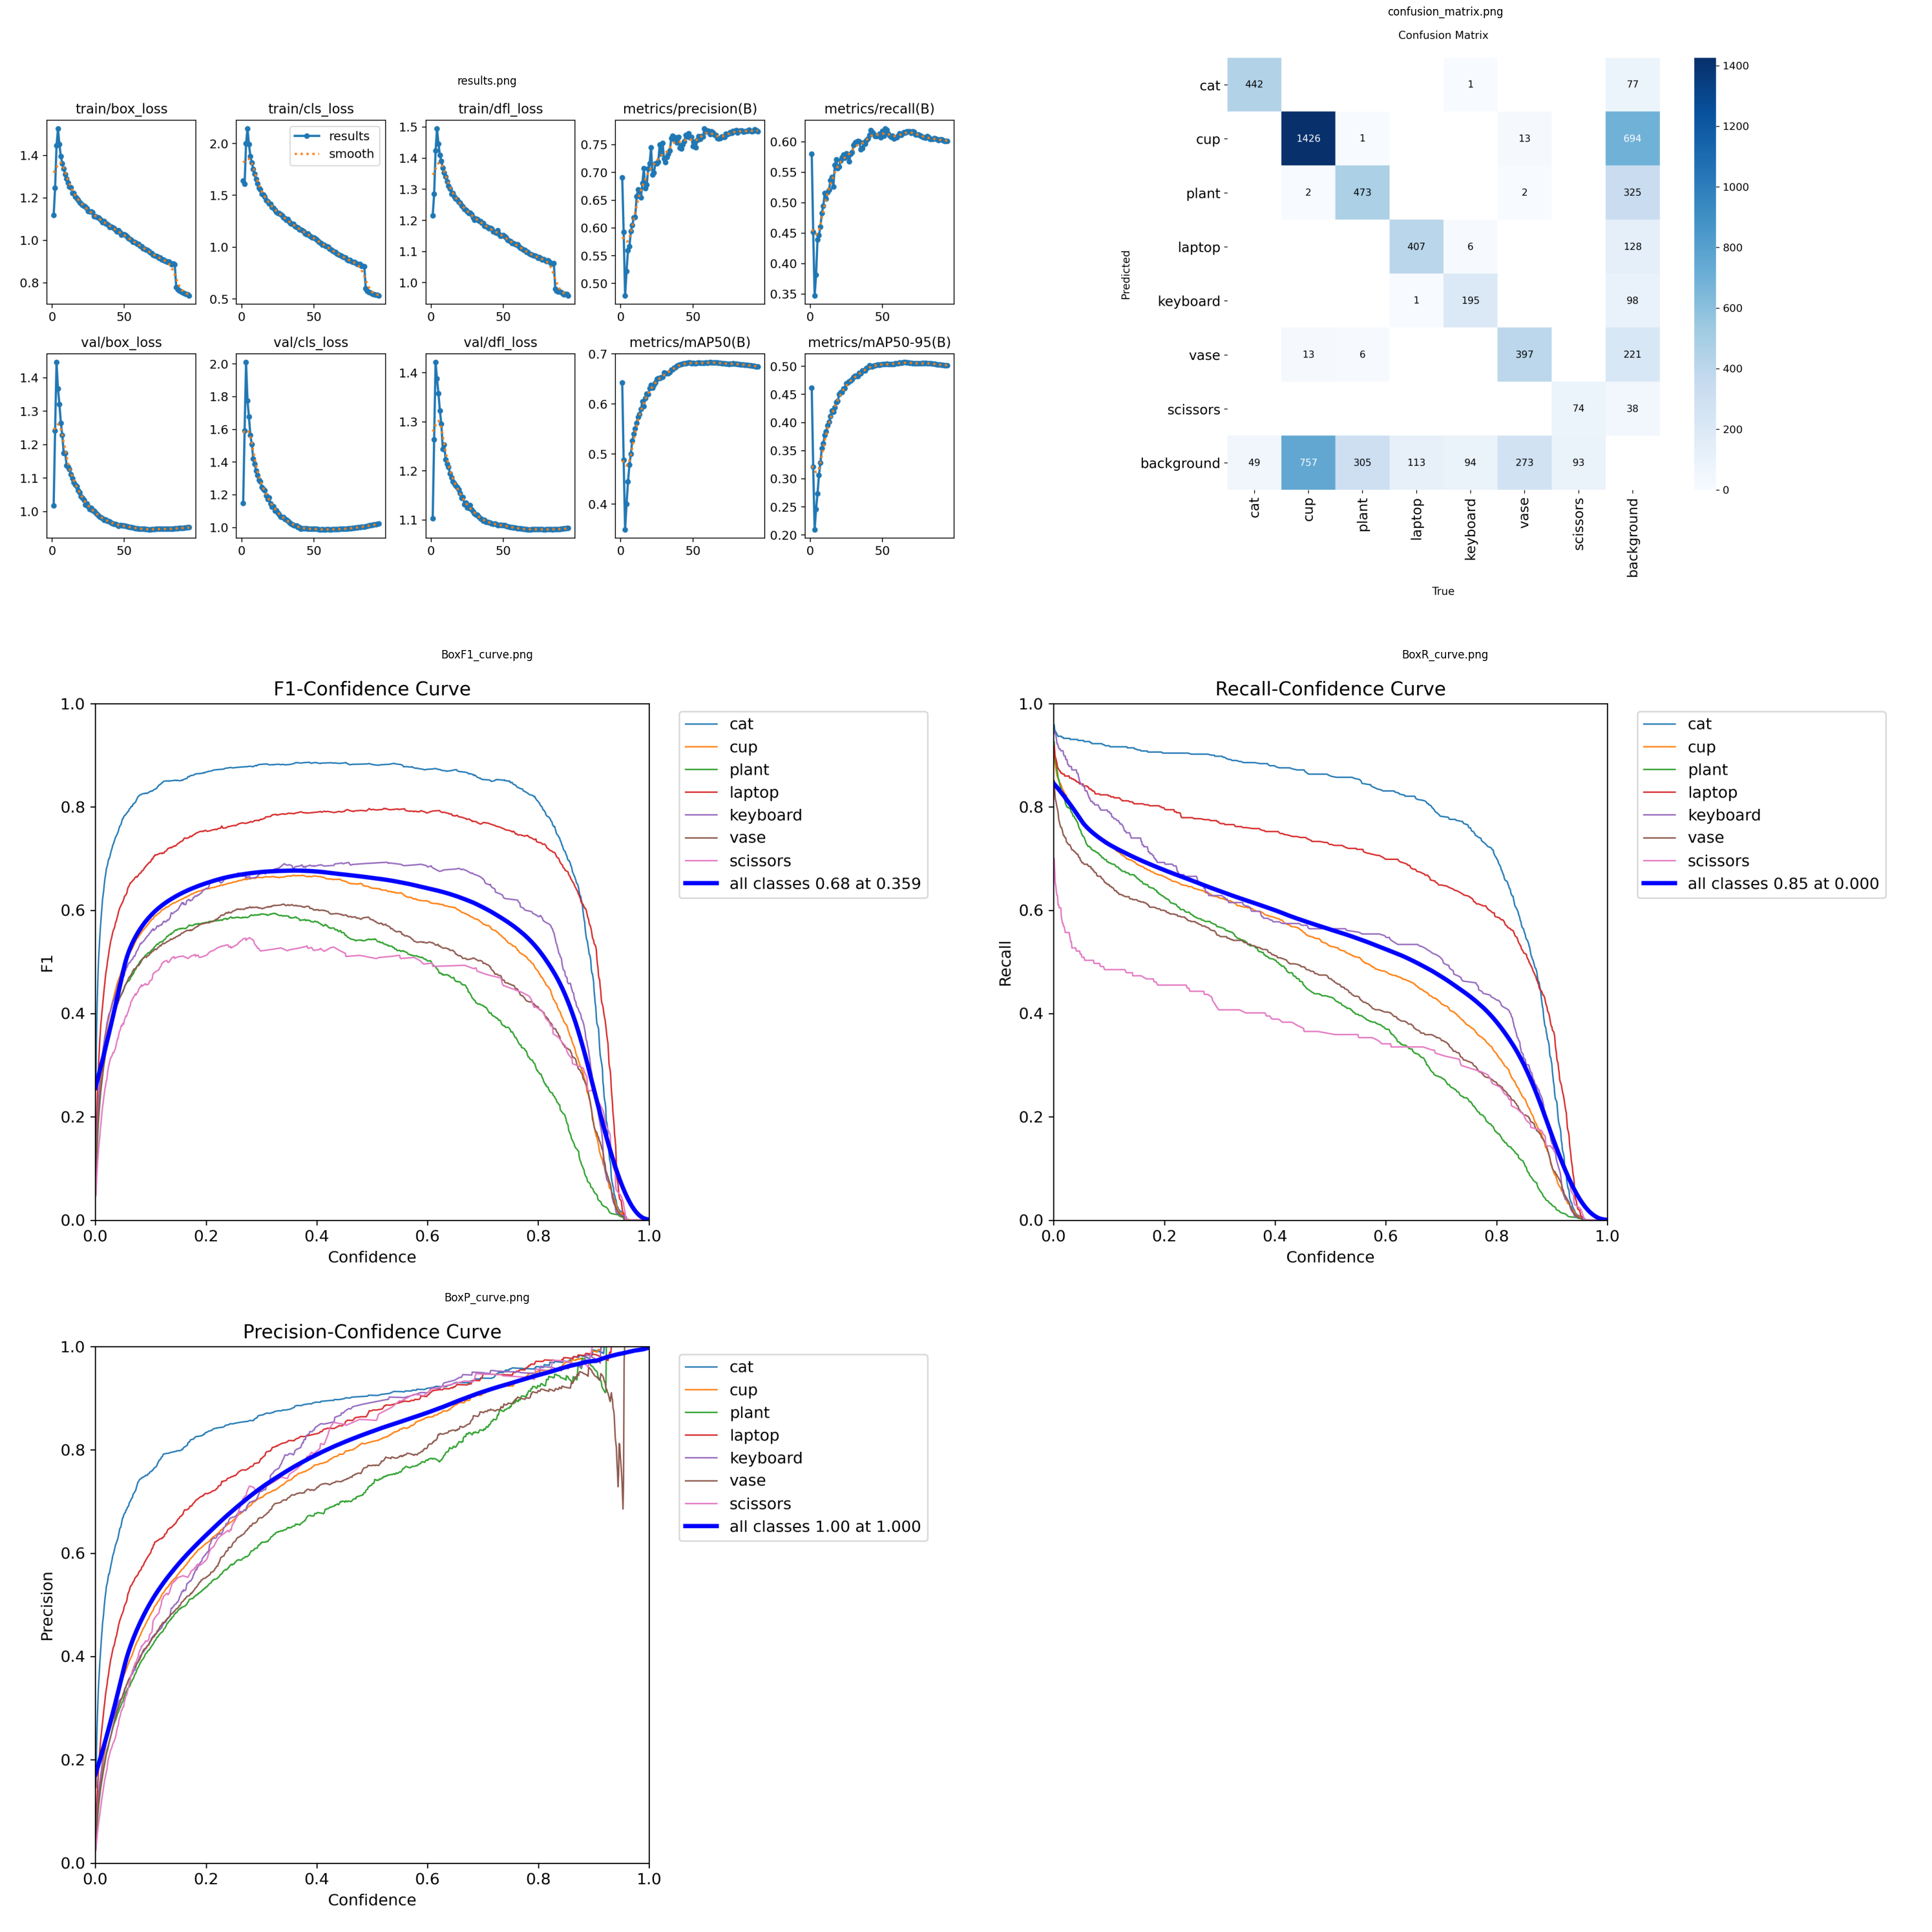

In [7]:
# Display training results for YOLOv8s
# Use the actual save directory returned by training to avoid hard-coded path mismatches.
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir=str(results.save_dir),
    num_images=5,
    num_cols=2
)

In [8]:
from ultralytics import YOLO
model = YOLO("runs/detect/runs/detect/train5_yolov8s-2/weights/best.pt")
metrics = model.val(data="curated_yolo/data.yaml", split="val", imgsz=640, batch=16, device=0, verbose=True)

Ultralytics 8.4.43  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 11,128,293 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 828.4489.1 MB/s, size: 121.5 KB)
val: Scanning C:\Users\User\Pet-mischief-detection\curated_yolo\labels\val.cache... 2259 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2259/2259  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 142/142 7.1it/s 20.1s0.1s
                   all       2259       5143      0.771      0.614      0.683      0.507
                   cat        415        491      0.889      0.883      0.909      0.713
                   cup        989       2198      0.754      0.599      0.681      0.505
                 plant        463        785      0.657      0.527      0.588      0.364
                laptop        349        521      0.823      0.758      0.812      0.